<center>
    
## <font color='maroon'>ASTR 21100</font>
## <font color='maroon'>Final Project: Classifying light curves with convolutional neural networks</font>
        
## <font color='blue'>Primary instructor(s) for this project: Andrey Kravtsov</font>
    
### <font color='blue'>50 points + possible extra credit points</font>

    
### <font color='blue'>Part I is due Fri, Feb 28 by 9pm; Part II is due Fri, Mar 7 , 9pm</font> 

### <font color='blue'>Final version is due Tue, Mar 11, 9pm</font> 


<p>



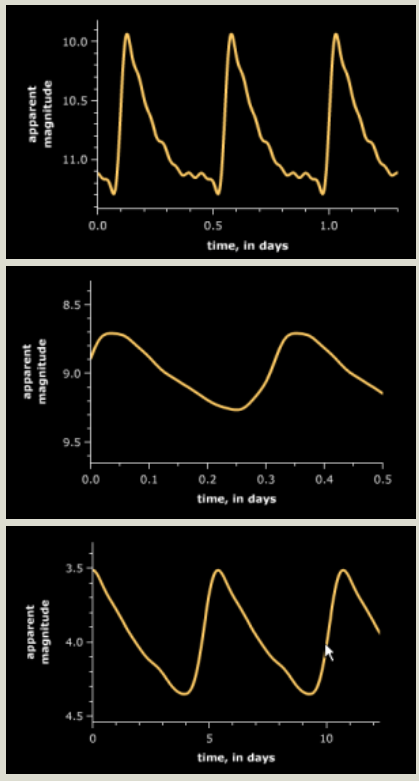

### <font color='blue'>Overview</font>

In this project, you will use convolutional neural networks to classify light curves from the [Optical Gravitational Lensing Experiment (OGLE)](https://ogledb.astrouw.edu.pl/~ogle/OCVS/), which has catologued thousands of variable stars.  

Computational methods and analysis techniques that you will use include:

* Creating 2D data visualizations and manipulating images

* Convolutional neural networks and deep learning

* Measuring the accuracy of machine learning results

### <font color='blue'>Background</font>

Many astronomical objects emit flux that varies with time. When variations of measured flux (often expressed as a magnitude) are plotted over time, the resulting graph is called a light curve.

Stars, in particular, vary for a variety of reasons. Although all star (including our Sun!) vary by a small amount, some stars vary a lot. The shape and form of the star's light curve can be used to understand what type of star we are observing and glean information about physical conditions within the star. 

However, classifying light curves in general presents challenges. Most light curves are irregularly sampled as a function of time, and often have gaps in coverage. Unfortunately, standard statistical methods that can be applied to well-sampled light curves may not work at all for sparsely sampled ones. Additionally, while it is easy to create a high-quality training sample of labeled light curves, there are many more light curves that are ambiguous and cannot confidently be labeled. This means that feature-based machine learning classifiers such as RandomForest are not able to perform well on large light curve datasets except under ideal data conditions.

In this project you will use a sample of variable star light curves from the [OGLE experiment](https://ogle.astrouw.edu.pl/), which has been operating for a couple of decades and is designed to detect variable stars. The experiment produced a large sample of variable stars of different types. As was hinted at in the previous paragraph, these light curves cover different timespans, and gaps in coverage are frequent. In this project, you will devise an algorithm that can classify these light curves with a high degree of confidence despite these challenges. 

More specifically, you will develop a classification scheme using a Convolutional Neural Network (CNN) method. Your CNN will learn to discriminate between light curves from a set of training data, and you will test the accuracy of the method using a set of testing data. The CNN method is known to produce excellent results in classifying objects in images. In this project you will explore some ideas of how light curves can be converted into images for classification with a CNN, which avoids some of the issues with classification mentioned above.

### <font color='blue'>Preparatory steps</font>

**(1) Complete required background reading**

* Read background information about convolutional neural networks. This can be found in the [Section 9.2]() of the notes and in Chapters 2 and 8 of Francois Chollet's book on deep learning (see PDF files of the chapters in the #proj_varstars_class channel on Slack).  Chollet is the creator of Keras, the package that you will be using to create your CNN.


* Read [Mahabal+2017](https://arxiv.org/pdf/1709.06257.pdf). This paper outlines how to turn light curves into images that can be fed into a CNN. It also describes different CNN architectures that you can try. Read sections III and IV in detail and skim the others according to your interest.


* Familiarize yourself with the [scikit-learn](https://scikit-learn.org/stable/index.html) Python library, which contains implementations of several machine learning techniques, as well as many functions that are useful for machine learning. Some functions that might be useful for this project include:
  * [sklearn.metrics.accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)
  * [sklearn.metrics.confusion_matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
  * [sklearn.model_selection.train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)


* This is optional, but you may be interested to review how light curves of different types of variable stars look in the OGLE database [here](http://ogle.astrouw.edu.pl/atlas/). An overview of variable stars and their light curves can be found in this [PDF file](https://www.aavso.org/sites/default/files//Variable%20Star%20Classification%20and%20Light%20Curves%20Manual%202.1.pdf).

<br>


**(2) Install necessary Python packages**

You will build your CNN with the [Keras](https://keras.io/) Python package, which is part of Google's [Tensorflow](https://www.tensorflow.org/). You can install Tensorflow in Ananconda with the following commands:

```
# Upgrade to latest pip
pip install --upgrade pip

# Install Tensorflow
pip install tensorflow
```

Once you have installed Tensorflow, you should be able to access Keras by running the following code:

```
from tensorflow import keras
```

If you run into any issues during the installation process, please reach out for help.

<br>

**(3) Get access to the project data**    

The data for this project is stored on Google Drive [here](https://drive.google.com/file/d/1n8YLnFRCDfSHKVkgIALD1CwvyPW0ZBuj/view?usp=sharing) (size 128 Mb). Download a copy of the dataset to your laptop. You can also copy the dataset to your Google Drive and use Google Colab to complete this project. If you choose to go this route, please reach out for assistance in connecting the dataset to your project notebook.

There are 50,000 light curves in the dataset, and each has been assigned a unique ID. You can use the provided `gcl` function below to read in light curves, as well as their OGLE IDs and assigned type. (If you are curious about a certain object, you can use the OGLE ID to look it up in the OGLE database!) For efficiency purposes, the light curves are stored in Python Numpy files with the extension `.npy`. If you have not worked with `.npy` files before, you can read more about them [here](https://numpy.org/devdocs/reference/generated/numpy.lib.format.html). 

Make sure that you can run the below code, which loads in a specific light curve given a  curve ID. The code also contains a list with all possible IDs for the provided dataset. Though you are welcome to devise different ways of loading in and working with the data, keep in mind that the dataset is quite large, and loading in too many light curves at once may cause issues. 

### <font color='blue'>Project description</font>

**Part I: Preprocessing (20 points)**

First, prepare the light curves to be classified by the CNN. Complete the following steps:

1. Write a function that takes in a light curve and returns a 2D array representing the dm-dt image of that light curve. The process of creating dm-dt images is described in [Mahabal+2017](https://arxiv.org/pdf/1709.06257.pdf). Note that you will have to adjust the bin boundaries in dm-dt space to better suit the OGLE data. (10 points)

2. Write a function that takes in one or more dm-dt images and produces a visualization of the image(s). Stacking multiple dm-dt images for objects in the same class will create a composite image like those shown in [Mahabal+2017](https://arxiv.org/pdf/1709.06257.pdf). The goal is for your composite images to be as visually distinct as possible between classes, so try adjusting the bin boundaries in dm-dt space to achieve this. (2 points)

3. Create dm-dt image arrays for every light curve in the dataset. Also create arrays of labels for the light curves based on their known classifications. The easiest way to do this is to assign each class an integer. When you do this, make sure to write down this encoding in your notebook so that you (and we) can keep the classes straight! (3 points) 

4. Divide the data into testing, training and validation sets. Stack the images in each set into data cubes so that they can be fed into the Keras CNN. Make the first trial runs and present preliminary results of your calculations. (5 points) 

Please note: Once you have figured out how to make dm-dt images, it is best to do steps 3 and 4 only once, and save the output to a file that can be loaded in each time you open your notebook again. Recreating the images each time will be a very slow and very intensive process for your computer. Please reach out if you need help with saving the images to a file!

**Part II: The CNN (30 points)**

Next, construct, train, and test your CNN using the prepared data. Complete the following steps:

1. Use Keras to define the CNN, following the "shallow" architecture outlined in [Mahabal+2017](https://arxiv.org/pdf/1709.06257.pdf). (5 points)

2. Train the CNN on the training data from Part I above. The validation data should be used during training as well, though it will be fed in separately from the training data. (5 points)

3. Test the CNN on the testing data from Part I above. Create a confusion matrix showing the results of your classification. (5 points)

4. Investigate the effects of using deeper architectures. Use information you read in the chapters from Chollet's book or the deeper architecture from [Mahabal+2017](https://arxiv.org/pdf/1709.06257.pdf). You are encouraged to explore your own architectures rather than just copying the example ones. Explore alternatives and try to improve the accuracy of classification as much as you can. Present the results of your best alternative architecture in the form of a confusion matrix and overall accuracy. (15 points)

### <font color='blue'>Extra-credit: experimenting with data augmentation (10 extra-credit points)</font>

One way that training efficiency can be improved is by using a trick called *data augmentation* to increase the size of the training sample. In this approach one takes existing light curves with reliable classifications and modifies them significantly enough to be different, but not too much that it would not be possible to classify the lightcurve. Such modification can take the form of introducing a gap in the data, resampling it to have a new period,  perturbing certain parts of the light curve with random Gaussian noise, etc. In consultation with the instructors, try to implement some of these strategies. Retrain your network on your augmented training data and try to improve the accuracy of classification. 


### Codes to

In [14]:
#Set this variable to be the path to the downloaded proj_light_curves_data folder
#If you put the data in the same directory as your notebook, this can be set to 'proj_light_curves_data/'
path_to_data = '/Users/jackc/downloads/proj_light_curves_data'

In [15]:
#Defines lists containing the IDs of different variable types in the database
#You can iterate over these lists to get all star IDs of a certain type
#Or you can pull a random entry from a list to get a random star for that class
cepheid = list(range(1,5001))
ecl = list(range(5001,10001))
rrly = list(range(10001,15001))
ds = list(range(15001,20001))
lpv = list(range(20001,25001))

#Defines a list containing the IDs of all stars in the database
#Iterate over this to iterate over every star
all_stars = list(range(1, 25001))

In [16]:
import os
import numpy as np

def glc(lc_id, return_extras=False, path_to_data=None):
    '''
    Gets the data for a given light curve. glc = "Get Light Curve"
    
    Parameters
    ----------
    lc_id : integer
        Light curve ID in the range [1,50000]

    return_extras: Boolean : default=False
        If True, the function will return all 3 items under "Returns"
        If False, the function will only return the light curve (lc)
        
    Returns
    -------
    lc : Numpy array with shape (3, len(lc))
        The light curve. lc[0] gives the time values, lc[1] gives the 
        magnitudes, and lc[2] gives the magnitude errors.
        
    lc_type : str
        The type of the light curve. Can be 'cepheid', 'ecl', 'rrly', 
        'ds' or 'lpv.' Returned only if return_extras is True.
        
    OGLE_id : str
        The OGLE ID of the light curve. Can be used to look up a star
        in the OGLE database. Returned only if return_extras is True.
    
    '''
    if path_to_data is None:
        print('Set path_to_data before using gcl!')
        
    lc = np.load(os.path.join(path_to_data, 'curves', str(lc_id) + '.npy'))
    with open(os.path.join(path_to_data, 'info.txt')) as file:
        lc_data = [line for line in file if line.startswith(str(lc_id))][0].split()
    lc_type, OGLE_id = lc_data[1:]
    if return_extras: return lc, lc_type, OGLE_id 
    return lc

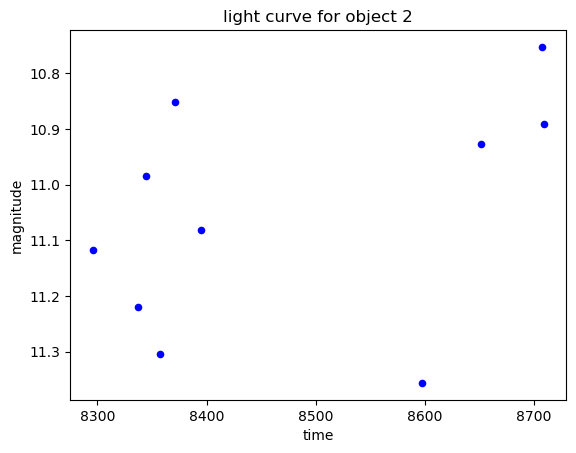

In [18]:
import matplotlib.pyplot as plt

#Specify a light curve here
lc_id = 2


#This code will graph the selected light curve
lc = glc(lc_id, path_to_data=path_to_data)
plt.scatter(lc[0], lc[1], s=20, c='b')
plt.xlabel('time')
plt.ylabel('magnitude')
plt.title('light curve for object ' + str(lc_id))
plt.gca().invert_yaxis()
plt.show()

In [32]:
images = []
labels = []
dm_bins = np.array([-8, -5, -3, -2.5, -2, -1.5, -1, -.5, -.3, -.2, -.1, 0, 0.1, 0.2, 0.3, 0.5, 1, 1.5, 2, 2.5, 3, 5, 8])
dt_bins = np.array([1/145, 2/145, 3/145, 4/145, 1/25, 2/25, 3/25, 1.5, 2.5, 3.5, 4.5, 5.5, 7, 10, 20, 30, 60, 90, 120, 240, 600, 960, 2000, 4000])
for i in range(1, 25000): 
    lc, lc_type, OGLE_id = glc(i, return_extras = True, path_to_data = path_to_data)
    times = lc[0]
    mags = lc[1] 
    dm = mags[:,None] - mags[None,:]
    dt = times[:,None] - times[None,:]
    #we want only unique pairs and no negative dt values: 
    dm = dm.ravel()
    dt = dt.ravel()
    mask = dt > 0
    dm = dm[mask]
    dt = dt[mask]
    H, xedges, yedges = np.histogram2d(dm, dt, bins = [dm_bins, dt_bins])
    #normalize histogram between 1 and 255
    n = len(times)
    p = n * (n - 1) // 2
    H_norm = (255 * H / p + 0.99999).astype(int)
    H_norm[H == 0] = 0

    #now we have to get a label as a star type!

    class_mapping = {
    "cepheid": 0,
    "ecl": 1,
    "rrly": 2,
    "ds": 3,
    "lpv":4 
        }
    star_type = class_mapping[lc_type]
    images.append(H_norm)
    labels.append(star_type)
    



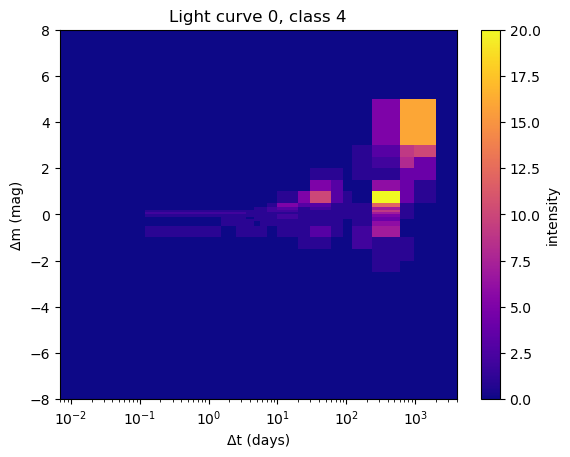

In [49]:
import matplotlib.pyplot as plt

plt.pcolormesh(dt_bins, dm_bins, images[24000], cmap="plasma")
plt.xscale("log")   # since dt bins are semi-log
plt.colorbar(label="intensity")
plt.xlabel("Δt (days)")
plt.ylabel("Δm (mag)")
plt.title(f"Light curve 0, class {labels[24000]}")
plt.show()


In [52]:
images = np.array(images)
labels = np.array(labels)

idx = np.random.permutation(len(labels))
images = images[idx]
labels = labels[idx]





17499 3750 3750


In [65]:
from sklearn.model_selection import train_test_split

X = torch.tensor(np.array(images), dtype=torch.float32)
y = torch.tensor(np.array(labels), dtype=torch.long)

# Add channel dimension (N, 1, H, W)
X = X.unsqueeze(1)

# Train/val/test split (example: 70/15/15)
from sklearn.model_selection import GroupShuffleSplit

groups = np.arange(1, 25000)  # one per sample

# First split into train and temp (val+test)
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, temp_idx = next(gss.split(X, y, groups=groups))

X_train, y_train, g_train = X[train_idx], y[train_idx], groups[train_idx]
X_temp, y_temp, g_temp    = X[temp_idx], y[temp_idx], groups[temp_idx]

# Then split temp into val and test
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(X_temp, y_temp, groups=g_temp))

X_val, y_val = X_temp[val_idx], y_temp[val_idx]
X_test, y_test = X_temp[test_idx], y_temp[test_idx]

In [66]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LightCurveCNN(nn.Module):
    def __init__(self, n_classes, input_channels=1):
        super().__init__()
        
        # Convolutional block
        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=3, padding=1)
        self.dropout1 = nn.Dropout(0.1)
        
        # Fully connected block
        self.fc1 = nn.Linear(32 * 23 * 22, 128)   
        self.dropout2 = nn.Dropout(0.25)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, n_classes)

    def forward(self, x):
        # Conv + ReLU
        x = F.relu(self.conv1(x))
        x = self.dropout1(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Dense layers
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = F.relu(self.fc2(x))
        
        # Final output (raw logits)
        x = self.fc3(x)
        return x

In [67]:
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LightCurveCNN(n_classes=len(set(labels)), input_channels=1)
model = model.to(device)


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3) #use simple preloaded loss and Adam optimizer

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64)
val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=64)
test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=64)




In [68]:
n_epochs = 20

for epoch in range(n_epochs):
    #Training
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(y_batch).sum().item()
        total += y_batch.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    #Validation
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(y_batch).sum().item()
            total += y_batch.size(0)

    val_loss /= total
    val_acc = correct / total

    print(f"Epoch {epoch+1}/{n_epochs} "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")


Epoch 1/20 Train Loss: 0.3379, Acc: 0.8745 Val Loss: 0.1933, Acc: 0.9363
Epoch 2/20 Train Loss: 0.1831, Acc: 0.9363 Val Loss: 0.1327, Acc: 0.9528
Epoch 3/20 Train Loss: 0.1526, Acc: 0.9471 Val Loss: 0.1376, Acc: 0.9581
Epoch 4/20 Train Loss: 0.1312, Acc: 0.9556 Val Loss: 0.1087, Acc: 0.9600
Epoch 5/20 Train Loss: 0.1192, Acc: 0.9587 Val Loss: 0.1144, Acc: 0.9619
Epoch 6/20 Train Loss: 0.1045, Acc: 0.9627 Val Loss: 0.1117, Acc: 0.9611
Epoch 7/20 Train Loss: 0.1001, Acc: 0.9659 Val Loss: 0.1185, Acc: 0.9587
Epoch 8/20 Train Loss: 0.0921, Acc: 0.9679 Val Loss: 0.1061, Acc: 0.9605
Epoch 9/20 Train Loss: 0.0841, Acc: 0.9703 Val Loss: 0.1075, Acc: 0.9648
Epoch 10/20 Train Loss: 0.0828, Acc: 0.9709 Val Loss: 0.1231, Acc: 0.9613
Epoch 11/20 Train Loss: 0.0784, Acc: 0.9721 Val Loss: 0.1031, Acc: 0.9664
Epoch 12/20 Train Loss: 0.0750, Acc: 0.9728 Val Loss: 0.0971, Acc: 0.9653
Epoch 13/20 Train Loss: 0.0700, Acc: 0.9757 Val Loss: 0.1140, Acc: 0.9648
Epoch 14/20 Train Loss: 0.0652, Acc: 0.9762 Val

In [69]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        _, predicted = outputs.max(1)
        correct += predicted.eq(y_batch).sum().item()
        total += y_batch.size(0)

print(f"Test Accuracy: {correct/total:.4f}")


Test Accuracy: 0.9693
